In [2]:
# alice viggiani
# 612 advanced gis
# December, 2025

## Language use and gentrification intensity in US urban areas

<small>Link to dashboard: https://www.undr.construction/languages-gentrification-dashboard</small>

**Data sources**<br>
<small>S1602 Limited English spoken at home, 2023, US Census<br>
Gentrification intensity map, 1990-2020, John Lauermann<br>
Spatial datasets, CBSA boundaries, tracts boundaries, Geographic relationship tracts, Census<br></small>

**Geography**<br>
<small>Four most populated metropolitan areas from the US, studied by tracts:<br>
16980 Chicago-Naperville-Elgin, IL-IN Metro Area<br>
19100 Dallas-Fort Worth-Arlington, TX Metro Area<br>
31080 Los Angeles-Long Beach-Anaheim, CA Metro Area<br>
35620  New York-Newark-Jersey City, NY-NJ Metro Area

**Intro**<br>
<small>The study seeks to visualize and interpret how the process of gentrification in US tracts relates to the languages spoken in households across the four most populous metropolitan areas. It investigates whether Census tracts with high gentrification scores coincide with a high concentration of residents who speak particular languages at home, such as Spanish, Western European, and Slavic languages.<br>
The preliminary spatial representation visually pairs the gentrification score and the concentration of the language spoken population, by each of the four metropolitan areas, and by each of the language agglomerations.<br>
The analysis of the datasets was conducted using Bivariate Moran’s I, Local Moran's I, and clusters, as well as the shares of how much of each language spoken population is exposed to gentrified or super-gentrified regions.</small>



**Summary**

**1. Data**<br>
<small>1.1 Languages dataset<br>
1.2 Spatial data base<br>
1.3 Gentrification intensity data<br>
<br></small>
**2. Visualizations**<br>
<small>2.1 Setup<br>
2.2 Computations<br>
<br></small>
**3. Spatial statistics**<br>
<small>3.1 Bivariate Moran's I<br>
3.2 Local Moran's I<br>
3.3 Shares of gentrification exposure index</small>


### **1. Setup**


In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
from IPython.display import display, HTML
import os

import esda
from esda.moran import Moran_BV, Moran_Local_BV
import libpysal as lps
import mapclassify
import matplotlib.pyplot as plt

import seaborn
import warnings

from geopandas import GeoDataFrame
from matplotlib import colors
from shapely.geometry import Point
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import fiona

In [62]:
# data to read

# df_languages-5.csv
# gdf_languages_tracts-14
# gdf_languages_tracts_gent-4.gpkg

# gdf
gdf_path = "./data/gdf_languages_tracts_gent-4.gpkg"
# fiona.listlayers(gdf_path)
gdf = gpd.read_file(gdf_path, layer="gdf_languages_tracts_gent_4")

In [ ]:
# checking

# confirming projection us albers
gdf = gdf.to_crs(5070)

# confirming non na
gdf.isna().any(axis=1).sum()

0

In [63]:
gdf.columns.tolist()

['geoid',
 'cbsa_code',
 'state_abbr',
 'STATE_FIPS',
 'COUNTY_FIP',
 'STCOFIPS',
 'TRACT_FIPS',
 'FIPS',
 'POPULATION',
 'POP_SQMI',
 'SQMI',
 'POPULATI_1',
 'POP20_SQMI',
 'Shape__Are',
 'Shape__Len',
 'index_right',
 'state_abb',
 'county_x',
 'tract_x',
 'geographic_area_name',
 'total',
 'english_only',
 'spanish',
 'french',
 'west_germanic_languages',
 'slavic_languages',
 'indo_european',
 'korean',
 'chinese',
 'vietnamese',
 'tagalog',
 'asian_others',
 'arabic',
 'west_european',
 'east_se_asian',
 'unspecified',
 'state_x',
 'geography',
 'tr2020gj',
 'CBSAFP',
 'Bach_pct_1990',
 'Bach_pct_2000',
 'Bach_pct_2010',
 'Bach_pct_2020',
 'Bach_pct_chg_1990to2000',
 'Bach_pct_chg_1990to2020',
 'Bach_pct_chg_2000to2010',
 'Bach_pct_chg_2010to2020',
 'classtype',
 'ConRent_mean_1990',
 'ConRent_mean_2000',
 'ConRent_mean_2010',
 'ConRent_mean_2020',
 'ConRent_mean_chg_1990to2000',
 'ConRent_mean_chg_1990to2020',
 'ConRent_mean_chg_2000to2010',
 'ConRent_mean_chg_2010to2020',
 'FAC_

In [64]:
# creating variables in percentage
languages = [
    "english_only",
    'spanish',
    "west_european",
    "east_se_asian",
    "slavic_languages",
    "indo_european",
    "arabic",
]

for i in languages:
    per = f"{i}_per"
    gdf[per] = round((gdf[i] / gdf["total"]) * 100, 2)

gdf["spanish_per"]

0        35.61
1        35.61
2         9.57
3        11.04
4        11.04
         ...  
12683    12.17
12684    10.15
12685     4.60
12686    10.46
12687    10.46
Name: spanish_per, Length: 12688, dtype: float64

In [65]:
# storing percentages variables
languages_per = [
    "english_only_per",
    'spanish_per',
    "west_european_per",
    "east_se_asian_per",
    "slavic_languages_per",
    "indo_european_per",
    "arabic_per",
]

# dropping rows with nan in any of those columns
cols = ["FAC_1990to2020"] + languages_per
gdf = gdf.dropna(subset=cols).copy()

print("rows after dropping NaNs:", len(gdf))

rows after dropping NaNs: 12492


**2. Spatial statistics**

In [66]:
# spatial weights matrix 
# using queen contiguity

# temporary weight
weights_temp = lps.weights.Queen.from_dataframe(
    gdf,
    use_index=False,
    silence_warnings=True
)
weights_temp

# identifying islands
gdf["islands"] = [len(weights_temp.neighbors[i]) for i in weights_temp.neighbors]

# dropping islands
gdf = gdf[gdf["islands"] > 0].copy()

# recalculating weights, so can disconsider islands
# weights for each row will sum to 1
weights = lps.weights.Queen.from_dataframe(
    gdf,
    use_index=False,
    silence_warnings=True
)
weights.transform = "r"

weights

In [67]:
# attribute similarity 
# using a spatial lag metric
# spanish speakers

y_spa = gdf["spanish_per"]

# spatial lag
# weighted average of spanish percentage in neighboring tracts
y_spa_lag = lps.weights.lag_spatial(w=weights, y=y_spa)

# store lag on df
gdf["spanish_lag"] = y_spa_lag
gdf["spanish_lag"]

0        21.407143
1        21.407143
2        28.600000
3        21.644286
4        21.644286
           ...    
12683    15.872222
12684    14.316842
12685     3.968571
12686     4.823750
12687     4.823750
Name: spanish_lag, Length: 12486, dtype: float64

In [86]:
# visual comparison between gentrification score and spatial lag

palette_5 = [
    "#fff098", 
    "#ffc05a", 
    "#ff995a", 
    "#f948e1", 
    "#b5009c"
    ]
color_5 = ListedColormap(palette_5)

gdf["cbsa_code"] = gdf["cbsa_code"].astype(str)

# equalizing color scale in all metros 
bins_fac = mapclassify.Quantiles(gdf["FAC_1990to2020"].dropna(), k=5).bins
bins_lag = mapclassify.Quantiles(gdf["spanish_lag"].dropna(), k=5).bins
edges_fac = [-np.inf] + list(bins_fac) + [np.inf]
edges_lag = [-np.inf] + list(bins_lag) + [np.inf]


# function to create several maps
def plot_cbsa_comparison(cbsa, gdf):
    # to create a map for each cbsa
    metro = gdf[gdf["cbsa_code"] == cbsa].copy()
    
    if metro.empty:
        print(f"No tracts found for metropolitan area {cbsa}")
        return
    
    f, ax = plt.subplots(1, 2, figsize=(16, 16))

    metro["fac_bin"] = pd.cut(metro["FAC_1990to2020"], bins=edges_fac, labels=False, include_lowest=True)
    metro["lag_bin"] = pd.cut(metro["spanish_lag"],   bins=edges_lag, labels=False, include_lowest=True)       

    # map 1
    # gentrification score
    metro.plot(
        column="fac_bin",
        ax=ax[0],
        edgecolor="none",
        cmap=color_5
    )
    # ax[0].axis(metro.total_bounds[np.asarray([0, 2, 1, 3])])
    # ax[0].set_title(f"{cbsa}, Gentrification score, 1990-2020")

    # map 2
    # spatial lag of spanish percentage
    metro.plot(
        column="lag_bin",
        ax=ax[1],
        edgecolor="none",
        scheme="quantiles",
        cmap=color_5,
        k=5
    )
    # ax[1].axis(metro.total_bounds[np.asarray([0, 2, 1, 3])])
    # ax[1].set_title("Spatial lag: Spanish, %")

    ax[0].axis("off")
    ax[1].axis("off")

    pdf_path = f"comparison-{cbsa}-gent_spanish_lag.pdf"
    plt.savefig(pdf_path, format="pdf", bbox_inches="tight")

    plt.show()

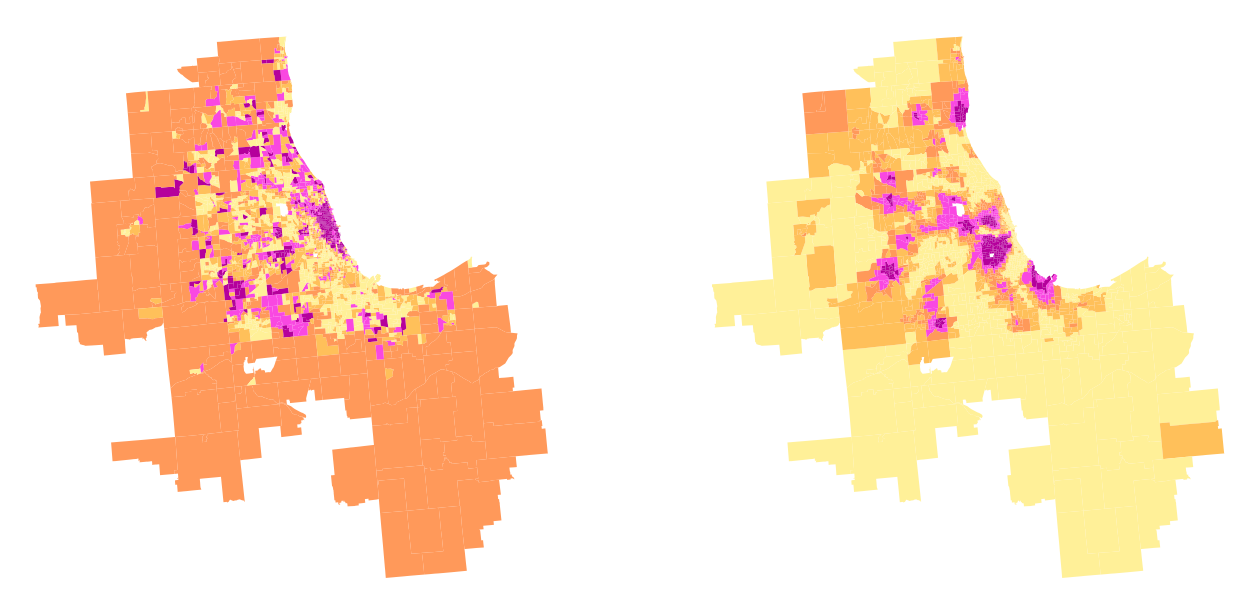

/opt/anaconda3/lib/python3.12/site-packages/mapclassify/classifiers.py:1767: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 4.
  self.bins = quantile(y, k=k)


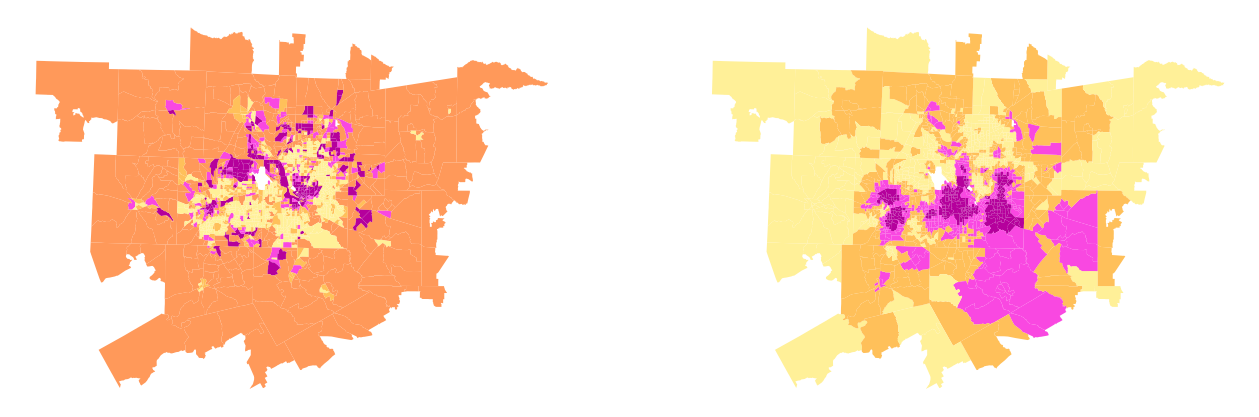

/opt/anaconda3/lib/python3.12/site-packages/mapclassify/classifiers.py:1767: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 3.
  self.bins = quantile(y, k=k)


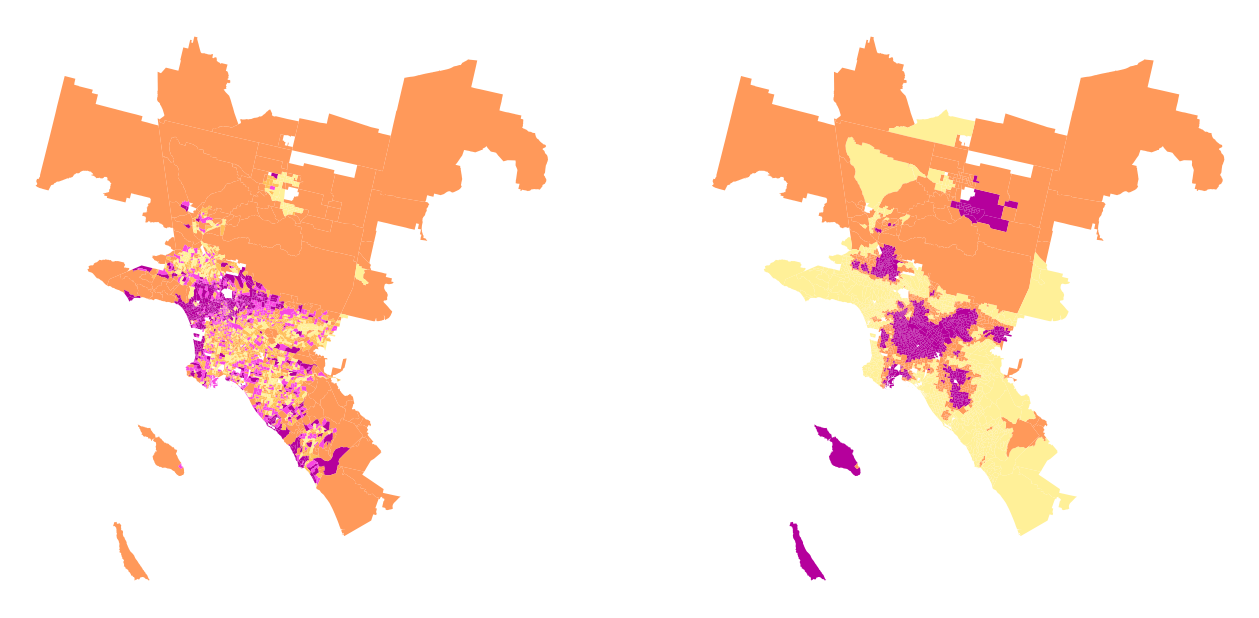

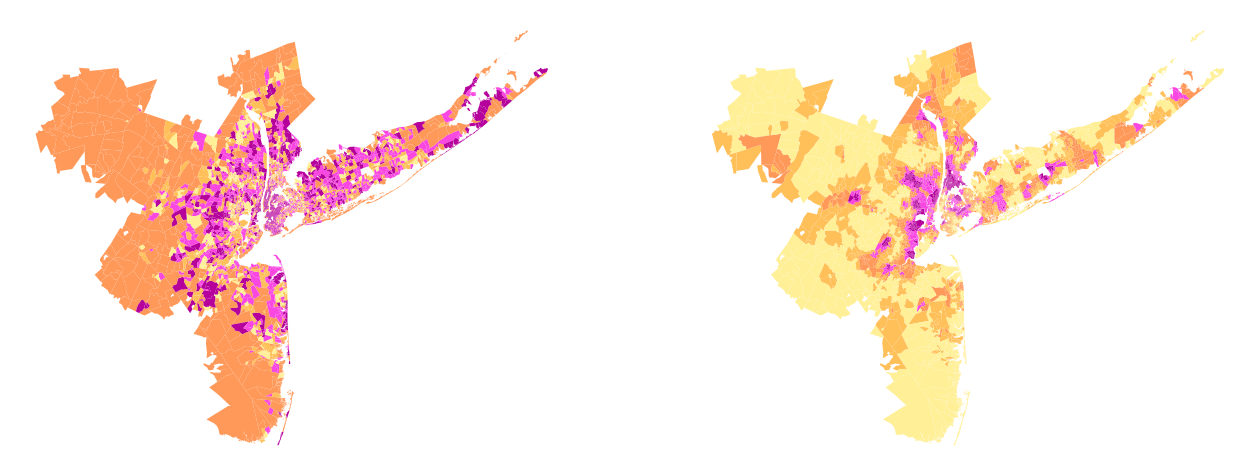

In [87]:
# printing and exporting 

plot_cbsa_comparison("16980", gdf)
plot_cbsa_comparison("19100", gdf)
plot_cbsa_comparison("31080", gdf)
plot_cbsa_comparison("35620", gdf)

**Bivariate Moran's I**

<small>Gentrification Intensity, 1990-2020<br>
Percentage of languages spoken at home<br></small>

In [88]:
# function to computing bivariate moran's i

def compute_mi_bv(lang, gdf, x_gent, y_lang, w):
    x = gdf[x_gent].values
    y = gdf[y_lang].values
    
    # random seed to simulate pseudo p-values
    np.random.seed(12345)
    mi_bv = Moran_BV(x, y, w)
    
    return {
        "language": lang,
        "I": round(mi_bv.I, 2),
        "p_value": round(mi_bv.p_sim, 3),
        "z_score": round(mi_bv.z_sim, 2)
    }

In [89]:
results = []

for i in languages_per:
    res = compute_mi_bv(
        lang=i,
        gdf=gdf,
        x_gent="FAC_1990to2020",
        y_lang=i,
        w=weights,
    )
    results.append(res)

results

[{'language': 'english_only_per',
  'I': 0.1,
  'p_value': 0.001,
  'z_score': 12.66},
 {'language': 'spanish_per', 'I': -0.18, 'p_value': 0.001, 'z_score': -23.68},
 {'language': 'west_european_per',
  'I': 0.07,
  'p_value': 0.001,
  'z_score': 9.19},
 {'language': 'east_se_asian_per',
  'I': 0.04,
  'p_value': 0.001,
  'z_score': 5.62},
 {'language': 'slavic_languages_per',
  'I': 0.08,
  'p_value': 0.001,
  'z_score': 10.31},
 {'language': 'indo_european_per',
  'I': 0.08,
  'p_value': 0.001,
  'z_score': 11.32},
 {'language': 'arabic_per', 'I': 0.01, 'p_value': 0.251, 'z_score': 0.65}]

In [92]:
# df with the results Bivariate Moran's I

df_mi_bv = pd.DataFrame(results)

df_mi_bv["language"] = df_mi_bv["language"]
df_mi_bv["I"] = df_mi_bv["I"]
df_mi_bv["p_value"] = df_mi_bv["p_value"]
df_mi_bv["z_score"] = df_mi_bv["z_score"]

df_mi_bv.to_csv("bivariate_moran-results-1.csv")
df_mi_bv

,language,I,p_value,z_score
0,english_only_per,0.10,0.001,12.66
1,spanish_per,-0.18,0.001,-23.68
2,west_european_per,0.07,0.001,9.19
3,east_se_asian_per,0.04,0.001,5.62
4,slavic_languages_per,0.08,0.001,10.31
5,indo_european_per,0.08,0.001,11.32
6,arabic_per,0.01,0.251,0.65


**Local Moran's I**

<small>Local indicators of Bivariate Spatial Association (LISA)<br>

x = gentrification intensity (FAC_1990to2020)<br>
y = % of a given language spoken at home</small>

In [93]:
# set up

# transforming in df
df_lisa = gdf.dropna(subset=["FAC_1990to2020", *languages_per]).copy()

# weights for lisa df
weights_lisa = lps.weights.Queen.from_dataframe(
    df_lisa,
    use_index=False,
    silence_warnings=True
)
weights_lisa.transform = "r"

# colors to be mapped later
colors_lisa = {
    "gent high, lang lag high": "#A8E746",
    "gent low, lang lag high": "#35C9F6",
    "gent low, lang lag low":  "#F948E1",
    "gent high, lang lag low": "#FFC05A",
    "not significant": "#F0F0F0",
}

# significance threshold
threshold = 0.05

In [105]:
# function to compute lisa for all languages

def compute_lisa(cbsa, lang_per, gdf, make_plot=True):
    cbsa = str(cbsa)

    cols = ["geoid", "cbsa_code", "FAC_1990to2020", lang_per, "geometry"]
    metro = (
        gdf.loc[gdf["cbsa_code"] == cbsa, cols]
        .dropna(subset=["FAC_1990to2020", lang_per])
        .copy()
    )

    if metro.empty:
        print(f"No tracts found for CBSA {cbsa}")
        return None, None, None, None

    lang_label = lang_per.replace("_per", "").replace("_", " ")
    print(
        "Clusters: Languages spoken at home and gentrification intensity\n"
        f"cbsa {cbsa}, {lang_label}: {len(metro)} tracts"
    )

    # weights
    w = lps.weights.Queen.from_dataframe(metro, use_index=False, silence_warnings=True)
    w.transform = "r"

    x = metro["FAC_1990to2020"].to_numpy(dtype=float)
    y = metro[lang_per].to_numpy(dtype=float)

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=RuntimeWarning, message="invalid value encountered in divide")
        lisa_bv = Moran_Local_BV(x=x, y=y, w=w)

    metro["Ii_bv"] = lisa_bv.Is
    metro["p_sim_bv"] = lisa_bv.p_sim
    metro["q_bv"] = lisa_bv.q
    metro["significant_bv"] = metro["p_sim_bv"] < threshold

    # cluster labels (same as yours)
    cluster = np.full(len(metro), "not significant", dtype=object)
    cluster[(metro["significant_bv"]) & (metro["q_bv"] == 1)] = "gent high, lang lag high"
    cluster[(metro["significant_bv"]) & (metro["q_bv"] == 2)] = "gent low, lang lag high"
    cluster[(metro["significant_bv"]) & (metro["q_bv"] == 3)] = "gent low, lang lag low"
    cluster[(metro["significant_bv"]) & (metro["q_bv"] == 4)] = "gent high, lang lag low"

    metro["cluster_bv"] = cluster
    metro["color_lisa"] = metro["cluster_bv"].map(colors_lisa)

    # shares for bars
    cluster_share = (
        metro["cluster_bv"]
        .value_counts(dropna=False)
        .rename_axis("cluster_bv")
        .reset_index(name="n")
    )
    cluster_share["per"] = (cluster_share["n"] / cluster_share["n"].sum() * 100).round(2)
    cluster_share["cbsa_code"] = cbsa
    cluster_share["lang_per"] = lang_per
    cluster_share["lang_label"] = lang_label

    # tags for later merges
    metro["lang_var"] = lang_per
    metro["lang_label"] = lang_label

    if make_plot:
        fig, ax = plt.subplots(1, 1, figsize=(6, 6))
        metro.plot(color=metro["color_lisa"], linewidth=0, ax=ax)
        ax.axis(metro.total_bounds[[0, 2, 1, 3]])
        ax.set_axis_off()
        plt.tight_layout()
        plt.show()

    metro_web = metro.to_crs(epsg=4326)
    return metro_web, w, lisa_bv, cluster_share


In [117]:
# create geojson for all languages of each metro

lang_vars = [
    "east_se_asian_per",
    "english_only_per",
    "indo_european_per",
    "slavic_languages_per",
    "spanish_per",
    "west_european_per",
]

cbsa = "31080"
metros = []

for lang in lang_vars:
    metro_web, w, lisa, share = compute_lisa(cbsa, lang, df_lisa, make_plot=False)
    if metro_web is not None:
        metros.append(metro_web)

gdf_all_lang = gpd.GeoDataFrame(
    pd.concat(metros, ignore_index=True),
    crs=metros[0].crs
)

# exporting
out_path = f"data/lisa_{cbsa}_all_languages.geojson"
# creating one id for each metro/language
gdf_all_lang["id"] = gdf_all_lang["geoid"].astype(str) + "_" + gdf_all_lang["lang_var"].astype(str)
gdf_all_lang.to_file(out_path, driver="GeoJSON")

gdf_all_lang.to_file(out_path, driver="GeoJSON")


Clusters: Languages spoken at home and gentrification intensity
cbsa 31080, east se asian: 3120 tracts
Clusters: Languages spoken at home and gentrification intensity
cbsa 31080, english only: 3120 tracts
Clusters: Languages spoken at home and gentrification intensity
cbsa 31080, indo european: 3120 tracts
Clusters: Languages spoken at home and gentrification intensity
cbsa 31080, slavic languages: 3120 tracts
Clusters: Languages spoken at home and gentrification intensity
cbsa 31080, spanish: 3120 tracts
Clusters: Languages spoken at home and gentrification intensity
cbsa 31080, west european: 3120 tracts


In [107]:
# df to store info for bar charts

metros_list = ["16980", "19100", "31080", "35620"]

lang_vars = [
    "east_se_asian_per",
    "english_only_per",
    "indo_european_per",
    "slavic_languages_per",
    "spanish_per",
    "west_european_per",
]

all_shares = []

for cbsa in metros_list:
    for lang in lang_vars:
        metro_web, w, lisa_bv, share = compute_lisa(cbsa, lang, df_lisa, make_plot=False)
        if share is None or share.empty:
            continue

        share = share.copy()
        share["cbsa_code"] = str(cbsa)
        share["lang_per"] = lang
        share["lang_label"] = lang.replace("_per", "").replace("_", " ")
        share["color_lisa"] = share["cluster_bv"].map(colors_lisa)

        all_shares.append(share)

df_bars = pd.concat(all_shares, ignore_index=True)
df_bars

Clusters: Languages spoken at home and gentrification intensity
cbsa 16980, east se asian: 2353 tracts
Clusters: Languages spoken at home and gentrification intensity
cbsa 16980, english only: 2353 tracts
Clusters: Languages spoken at home and gentrification intensity
cbsa 16980, indo european: 2353 tracts
Clusters: Languages spoken at home and gentrification intensity
cbsa 16980, slavic languages: 2353 tracts
Clusters: Languages spoken at home and gentrification intensity
cbsa 16980, spanish: 2353 tracts
Clusters: Languages spoken at home and gentrification intensity
cbsa 16980, west european: 2353 tracts
Clusters: Languages spoken at home and gentrification intensity
cbsa 19100, east se asian: 1724 tracts
Clusters: Languages spoken at home and gentrification intensity
cbsa 19100, english only: 1724 tracts
Clusters: Languages spoken at home and gentrification intensity
cbsa 19100, indo european: 1724 tracts
Clusters: Languages spoken at home and gentrification intensity
cbsa 19100, sl

,cluster_bv,n,per,cbsa_code,lang_per,lang_label,color_lisa
0,not significant,1397,59.37,16980,east_se_asian_per,east se asian,#F0F0F0
1,"gent low, lang lag low",562,23.88,16980,east_se_asian_per,east se asian,#F948E1
2,"gent low, lang lag high",157,6.67,16980,east_se_asian_per,east se asian,#35C9F6
3,"gent high, lang lag high",143,6.08,16980,east_se_asian_per,east se asian,#A8E746
4,"gent high, lang lag low",94,3.99,16980,east_se_asian_per,east se asian,#FFC05A
...,...,...,...,...,...,...,...
115,not significant,3759,77.01,35620,west_european_per,west european,#F0F0F0
116,"gent low, lang lag low",558,11.43,35620,west_european_per,west european,#F948E1
117,"gent low, lang lag high",244,5.00,35620,west_european_per,west european,#35C9F6
118,"gent high, lang lag low",208,4.26,35620,west_european_per,west european,#FFC05A


In [111]:
cluster_order = [
    "gent high, lang lag high",
    "gent low, lang lag high",
    "gent low, lang lag low",
    "gent high, lang lag low",
    "not significant",
]

df_bars["cluster_bv"] = pd.Categorical(df_bars["cluster_bv"], categories=cluster_order, ordered=True)
df_bars = df_bars.sort_values(["cbsa_code", "lang_per", "cluster_bv"])
df_bars

,cluster_bv,n,per,cbsa_code,lang_per,lang_label,color_lisa
3,"gent high, lang lag high",143,6.08,16980,east_se_asian_per,east se asian,#A8E746
2,"gent low, lang lag high",157,6.67,16980,east_se_asian_per,east se asian,#35C9F6
1,"gent low, lang lag low",562,23.88,16980,east_se_asian_per,east se asian,#F948E1
4,"gent high, lang lag low",94,3.99,16980,east_se_asian_per,east se asian,#FFC05A
0,not significant,1397,59.37,16980,east_se_asian_per,east se asian,#F0F0F0
...,...,...,...,...,...,...,...
119,"gent high, lang lag high",112,2.29,35620,west_european_per,west european,#A8E746
117,"gent low, lang lag high",244,5.00,35620,west_european_per,west european,#35C9F6
116,"gent low, lang lag low",558,11.43,35620,west_european_per,west european,#F948E1
118,"gent high, lang lag low",208,4.26,35620,west_european_per,west european,#FFC05A


Clusters: Languages spoken at home and gentrification intensity
cbsa 16980, east se asian: 2353 tracts


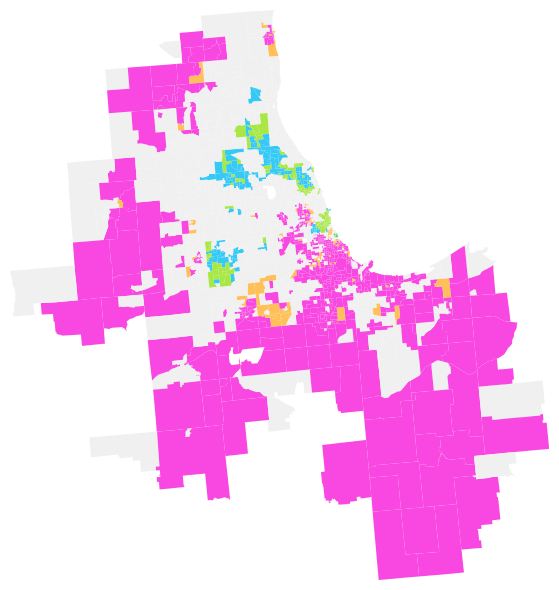

(             geoid cbsa_code  FAC_1990to2020  east_se_asian_per  \
 3294   17031804509     16980       -0.781102               5.69   
 3295   17031230600     16980       -0.107595               0.00   
 3296   17031823702     16980       -0.865502               0.72   
 3297   17031520100     16980        0.346619               0.00   
 3298   17031800500     16980        1.107028               0.98   
 ...            ...       ...             ...                ...   
 12667  55059000604     16980        0.055006               0.79   
 12668  55059002606     16980        1.158501               1.05   
 12669  55059001800     16980       -0.747544               0.00   
 12670  55059003002     16980        0.000000               0.00   
 12686  55127001701     16980        0.000000               0.00   
 
                                                 geometry     Ii_bv  p_sim_bv  \
 3294   MULTIPOLYGON (((-88.15396 42.00823, -88.15418 ... -0.188580     0.230   
 3295   MULTIPOLYGON

In [100]:
#chicago
compute_lisa("16980", "east_se_asian_per", df_lisa)
# east_se_asian_per
# english_only_per
# indo_european_per
# slavic_languages_per
# spanish_per
# west_european_per


In [ ]:
# printing bar charts

outdir = "./bars"
os.makedirs(outdir, exist_ok=True)

for (cbsa, lang), dfp in bars_df.groupby(["cbsa_code", "lang_per"], sort=False):
    dfp = dfp.sort_values("cluster_bv")

    fig, ax = plt.subplots(1, 1, figsize=(3, 5))

    bars = ax.barh(
        dfp["cluster_bv"].astype(str),
        dfp["per"],
        color=dfp["color_lisa"],
        height=0.6   # ≈ 16px visually
    )

    ax.set_xlim(0, 100)
    ax.set_title(f"{cbsa}\n{lang.replace('_per','').replace('_',' ')}")
    ax.invert_yaxis()

    # labels
    for bar, val in zip(bars, dfp["per"]):
        ax.text(
            0,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%",
            va="center",
            ha="left",
            fontsize=9
        )

    # no ax
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xticks([])
    ax.set_xlabel("")
    ax.set_yticks([])
    ax.tick_params(axis="both", length=0)

    # plt.tight_layout()

    # save
    fname = f"bars_cbsa_{cbsa}_{lang}.pdf"
    plt.savefig(os.path.join(outdir, fname), format="pdf", bbox_inches="tight")

    plt.close(fig)


**Web map**<br>
<small>The geojson files created were uploaded as tilesets or layers in Mapbox and ArcGIS Pro:<br>
mapbox://styles/aliceviggiani/cmj2lzevp006h01s23e6f4ma7<br>
https://undr-construction.webflow.io/languages-gentrification-dashboard</small>


In [ ]:
# Spanish speakers groups: cluster away from gentrification
# Anglophone, European, and some Asian groups: cluster with gentrification
# Arabic groups: Not relevant results

**Considerations**<br>
<small>Local Moran’s I highlights where gentrification intensity and language concentration are most related across each metropolitan area. Overall, the analysis shows a non-uniform exposure to super-gentrified and gentrified tracts among the languages spoken groups. Again, the most notorious result is from the Spanish-speaking community, which has the lowest exposure of 3.5%. This metric reinforces the primary analysis of a strong negative spatial association between Spanish speakers population and gentrification scores.

In contrast, Slavic speakers, 8%, Indo-European speakers, 7.5%, and English-only speakers, 7.2%, show the highest exposure, indicating that the most gentrification processes happen in areas with higher concentrations of these groups. Overall, the findings suggest that there is a relationship between the process of gentrification and the languages spoken at home in US metropolitan areas. Specifically, it intensifies in English and European-origin languages higher concentrations, while largely bypassing areas with higher concentrations of Spanish speakers residents.</small>
